#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import RFECV

#### Import sample data and drop uneccessary columns

In [3]:
data_for_model = pd.read_pickle("data/abc_classification_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['signup_flag', 'distance_from_store', 'gender', 'credit_score',
       'total_sales', 'total_items', 'transaction_count', 'product_area_count',
       'average_basket_value'],
      dtype='object')


#### Shuffle data

In [4]:
data_for_model = shuffle(data_for_model, random_state = 42)
print(data_for_model)

     signup_flag  distance_from_store gender  credit_score  total_sales  \
714            0                 1.64      M          0.58        27.81   
605            0                 0.88      M          0.63        26.62   
120            0                 0.56      M          0.62       886.78   
208            0                 0.11      M          0.58      1256.19   
380            0                 1.32      M          0.36       739.67   
..           ...                  ...    ...           ...          ...   
71             0                 0.07      M          0.57       746.15   
106            0                 1.96      F          0.60       881.49   
270            0                 1.59      M          0.50       319.37   
435            0                 0.71      F          0.54       273.94   
102            0                 2.60      F          0.48       523.41   

     total_items  transaction_count  product_area_count  average_basket_value  
714            6   

#### Class Balance

In [5]:
data_for_model["signup_flag"].value_counts(normalize = True)

signup_flag
0    0.689535
1    0.310465
Name: proportion, dtype: float64

#### Dealing with missing values

In [6]:
data_for_model.isna().sum()

signup_flag             0
distance_from_store     5
gender                  5
credit_score            8
total_sales             0
total_items             0
transaction_count       0
product_area_count      0
average_basket_value    0
dtype: int64

In [8]:
data_for_model.dropna(how = "any", inplace = True)

#### Dealing with outliers

In [15]:
outlier_investigation = data_for_model.describe()

outlier_columns = ["distance_from_store", "total_sales", "total_items"]

# Boxplot approach

for column in outlier_columns:

    lower_quartile = data_for_model[column].quantile(0.25)
    upper_quartile = data_for_model[column].quantile(0.75)
    iqr = upper_quartile - lower_quartile
    iqr_extended = iqr * 2
    min_border = lower_quartile - iqr_extended
    max_border = upper_quartile + iqr_extended

    outliers = data_for_model[(data_for_model[column] < min_border) | (data_for_model[column] > max_border)]
    print(f"{len(outliers)} outliers detected in column {column}")

    data_for_model.drop(outliers.index, inplace = True)

8 outliers detected in column distance_from_store
54 outliers detected in column total_sales
3 outliers detected in column total_items


#### Split input variables and output variables

In [16]:
X = data_for_model.drop(["signup_flag"], axis = 1)
y = data_for_model["signup_flag"]

#### Split out training and test sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Dealing with categorical variables

In [18]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [19]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   0.07          0.57       746.15          133   
1                   0.20          0.57       585.46          128   
2                   3.07          0.53      1151.24          226   
3                   2.86          0.77        14.03            8   
4                   0.52          0.52       656.48          121   
..                   ...           ...          ...          ...   
620                 0.39          0.72       564.47          146   
621                 1.62          0.72       793.91          171   
622                 2.60          0.65       847.01          123   
623                 0.36          0.45       924.07          189   
624                 1.36          0.59       429.66           95   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   24                   5             31.089583       1.0  
1                   32       

#### Feature scaling

In [20]:
scale_norm = MinMaxScaler()
X_train = pd.DataFrame(scale_norm.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(scale_norm.transform(X_test), columns = X_test.columns)

In [21]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0               0.014028      0.500000     0.296080     0.416404   
1               0.040080      0.500000     0.232113     0.400631   
2               0.615230      0.435484     0.457336     0.709779   
3               0.573146      0.822581     0.004642     0.022082   
4               0.104208      0.419355     0.260385     0.378549   
..                   ...           ...          ...          ...   
620             0.078156      0.741935     0.223758     0.457413   
621             0.324649      0.741935     0.315092     0.536278   
622             0.521042      0.629032     0.336230     0.384858   
623             0.072144      0.306452     0.366906     0.593060   
624             0.272545      0.532258     0.170093     0.296530   

     transaction_count  product_area_count  average_basket_value  gender_M  
0             0.560976                1.00              0.284911       1.0  
1             0.756098       

#### Feature Selection

In [22]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state = 42)
feature_selector = RFECV(clf)

fit = feature_selector.fit(X_train, y_train)

optimal_feature_count = feature_selector.n_features_
print(f"Optimal number of features : {optimal_feature_count}")

Optimal number of features : 6


In [23]:
X_train = X_train.loc[:, feature_selector.get_support()]
X_test = X_test.loc[:, feature_selector.get_support()]
print(X_train)

     distance_from_store  total_sales  transaction_count  product_area_count  \
0               0.014028     0.296080           0.560976                1.00   
1               0.040080     0.232113           0.756098                0.75   
2               0.615230     0.457336           0.829268                1.00   
3               0.573146     0.004642           0.024390                0.25   
4               0.104208     0.260385           0.365854                0.50   
..                   ...          ...                ...                 ...   
620             0.078156     0.223758           0.585366                0.75   
621             0.324649     0.315092           0.463415                0.50   
622             0.521042     0.336230           0.512195                1.00   
623             0.072144     0.366906           0.463415                0.50   
624             0.272545     0.170093           0.609756                1.00   

     average_basket_value  gender_M  
0

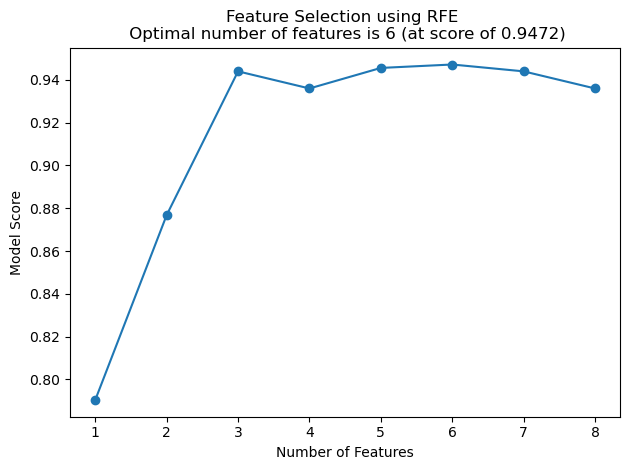

In [24]:
plt.plot(range(1, len(fit.cv_results_['mean_test_score']) + 1), fit.cv_results_['mean_test_score'], marker = "o")
plt.ylabel("Model Score")
plt.xlabel("Number of Features")
plt.title(f"Feature Selection using RFE \n Optimal number of features is {optimal_feature_count} (at score of {round(max(fit.cv_results_['mean_test_score']),4)})")
plt.tight_layout()
plt.show()

#### Model training

In [25]:
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Model Assessment

In [26]:
y_pred_class = clf.predict(X_test)
print(y_pred_class)

[0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0]


In [27]:
y_pred_prob = clf.predict_proba(X_test)[:,1]
print(y_pred_prob)

[0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.2 0.  0.2 0.  0.
 0.  0.  0.2 0.4 0.4 1.  0.  0.  0.2 0.2 0.4 0.  1.  1.  0.4 0.  0.  0.
 1.  0.  0.  0.8 0.  0.  0.  0.2 0.  0.2 0.6 0.  0.4 0.  0.  0.  0.  0.
 0.4 0.2 1.  0.2 0.  0.6 1.  0.  0.2 0.2 0.2 0.  0.  0.  0.4 0.  1.  0.
 0.  0.  0.  0.6 1.  0.6 0.  0.  0.  0.  0.  0.8 0.  0.  0.  1.  0.  0.
 0.  0.  0.4 0.  0.  0.  0.  0.  0.8 0.4 0.6 0.  0.  1.  0.  0.6 0.2 1.
 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  1.  0.  0.  1.  0.  0.6 0.  0.  1.  0.  1.  0.4 0.  1.  0.  0.8
 0.  0.  0.  0.  0.  0.  0.  0.8 0.  0.  0.  1.  0. ]


#### Confusion matrix

In [28]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
print(conf_matrix)

[[115   0]
 [ 10  32]]


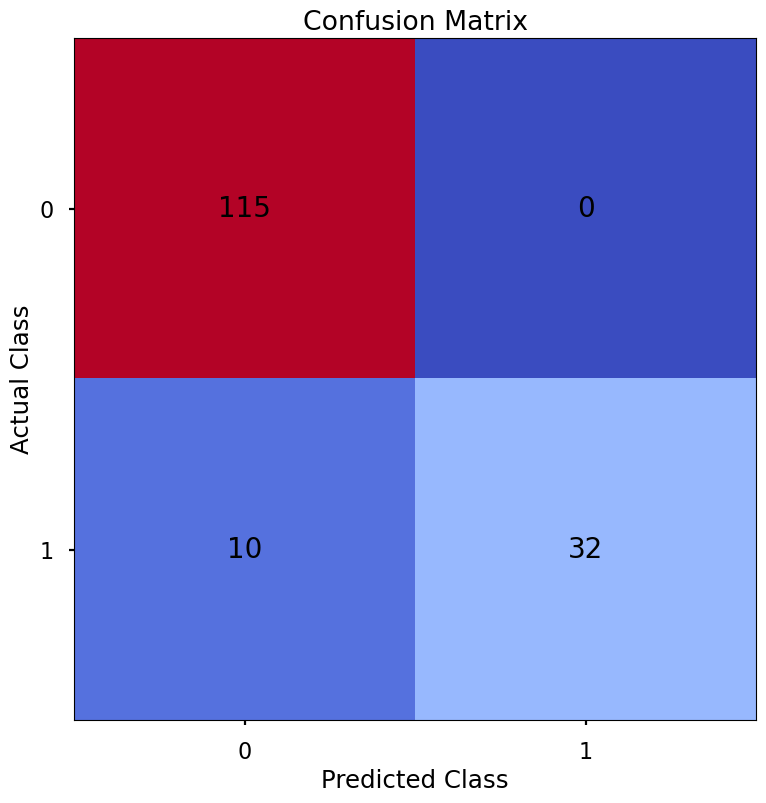

In [29]:
plt.style.use("seaborn-v0_8-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)
plt.show()

#### Accuracy (the number of correct classification out of all attempted classifications)

In [30]:
accuracy_score(y_test, y_pred_class)

0.9363057324840764

#### Precision (of all observations that were predicted as positive, how many were actually positive)

In [31]:
precision_score(y_test, y_pred_class)

1.0

#### Recall (of all positive observations, how many did we predict as positive)

In [32]:
recall_score(y_test, y_pred_class)

0.7619047619047619

#### F1-Score (the harmonic mean of precision and recall)

In [35]:
f1_score(y_test, y_pred_class)

0.8648648648648649

#### Finding the optimal value of k

In [38]:
k_list = list(range(2,25))
accuracy_scores = []

for k in k_list:

    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = f1_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

max_accuracy = max(accuracy_scores)
max_accuracy_idx = accuracy_scores.index(max_accuracy)
optimal_k_value = k_list[max_accuracy_idx]
print(optimal_k_value)

5


#### Plot of max depths

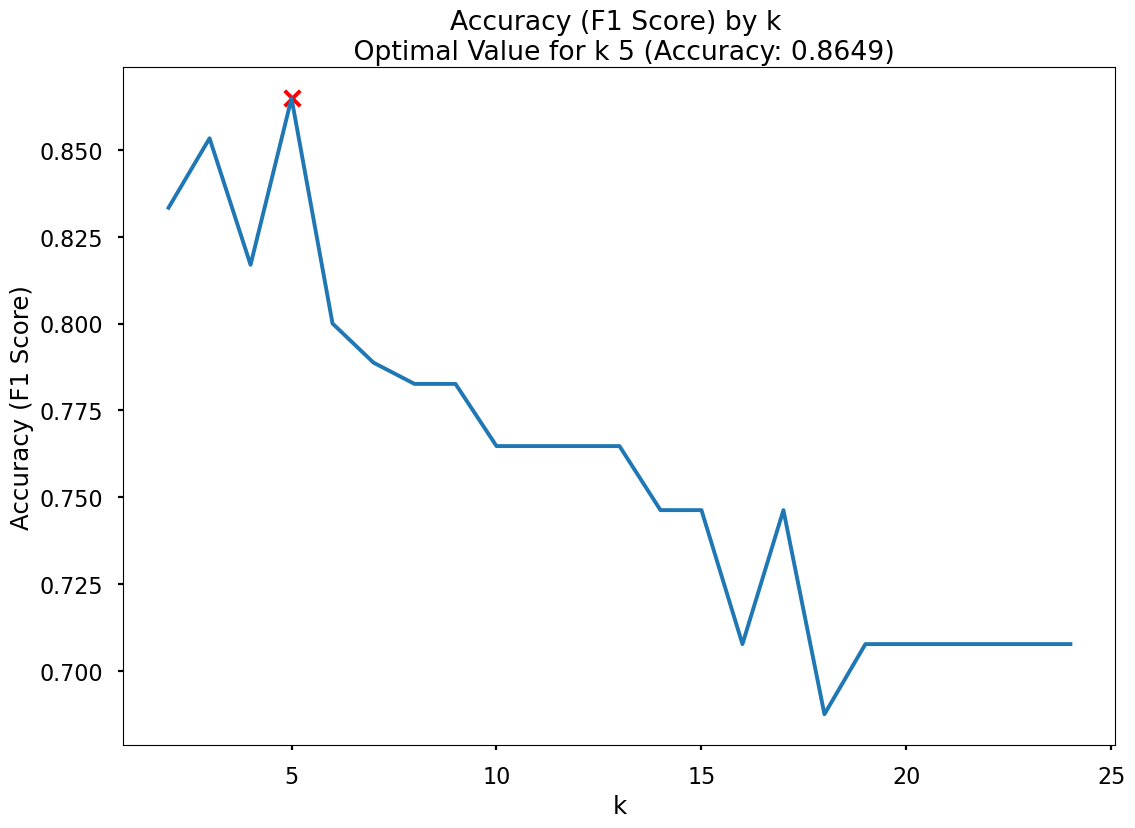

In [39]:
plt.plot(k_list,accuracy_scores)
plt.scatter(optimal_k_value,max_accuracy,marker = "x", color = "red")
plt.title(f"Accuracy (F1 Score) by k \n Optimal Value for k {optimal_k_value} (Accuracy: {round(max_accuracy,4)})")
plt.xlabel("k")
plt.ylabel("Accuracy (F1 Score)")
plt.tight_layout
plt.show()